# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**: https://www.kaggle.com/datasets/marikastewart/employee-turnover
2. **Research Goal**: membuat model untuk mendeteksi karyawan yang ingin resign berdasarkan kolom yang ada pada dataset


## About Dataset (Context)

> This database is from a large US company (no name given for privacy reasons). The management department is worried about the relatively high turnover. They want to find ways to reduce the number of employees leaving the company and to better understand the situation, which employees are more likely to leave, and why.
The data

> The HR department has assembled data on almost 10,000 employees who left the company between 2016-2020. They used information from exit interviews, performance reviews, and employee records.

## COlumn
| Field Name | Field Type | Description | Variable Type |
| :--- | :--- | :--- | :--- |
| department | string | The department the employee belongs to. | Qualitative - Nominal |
| promoted | int | 1 if the employee was promoted in the previous 24 months, 0 otherwise. | Qualitative - Nominal (Binary) |
| review | float | The composite score the employee received in their last evaluation. | Quantitative - Continuous |
| projects | int | How many projects the employee is involved in. | Quantitative - Discrete |
| salary | string | For confidentiality reasons, salary comes in three tiers: low, medium, high. | Qualitative - Ordinal |
| tenure | float | How many years the employee has been at the company. | Quantitative - Continuous |
| satisfaction | float | A measure of employee satisfaction from surveys. | Quantitative - Continuous |
| bonus | int | 1 if the employee received a bonus in the previous 24 months, 0 otherwise. | Qualitative - Nominal (Binary) |
| avg_hrs_month | float | The average hours the employee worked in a month. | Quantitative - Continuous |
| left | string | "yes" if the employee ended up leaving, "no" otherwise. | Qualitative - Nominal (Binary) |


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import kagglehub
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import os

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
path = kagglehub.dataset_download("marikastewart/employee-turnover")
!mv "{path}/employee_churn_data.csv" /content
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'employee-turnover' dataset.
mv: cannot remove '/kaggle/input/employee-turnover/employee_churn_data.csv': Read-only file system
Path to dataset files: /kaggle/input/employee-turnover


In [3]:
df = pd.read_csv('/content/employee_churn_data.csv')
df.head(10)

,department,promoted,review,projects,salary,tenure,satisfaction,bonus,avg_hrs_month,left
0,operations,0,0.577569,3,low,5.0,0.626759,0,180.866070,no
1,operations,0,0.751900,3,medium,6.0,0.443679,0,182.708149,no
2,support,0,0.722548,3,medium,6.0,0.446823,0,184.416084,no
3,logistics,0,0.675158,4,high,8.0,0.440139,0,188.707545,no
4,sales,0,0.676203,3,high,5.0,0.577607,1,179.821083,no
5,IT,0,0.683206,2,medium,5.0,0.565252,1,178.841879,no
6,admin,0,0.620158,4,high,5.0,0.686951,0,181.142956,no
7,support,0,0.499567,4,medium,7.0,0.720451,1,184.977538,no
8,sales,0,0.652818,4,low,6.0,0.678696,0,183.655790,no
9,sales,0,0.642031,3,medium,6.0,0.623365,0,181.851000,no


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9540 entries, 0 to 9539
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   department     9540 non-null   object 
 1   promoted       9540 non-null   int64  
 2   review         9540 non-null   float64
 3   projects       9540 non-null   int64  
 4   salary         9540 non-null   object 
 5   tenure         9540 non-null   float64
 6   satisfaction   9540 non-null   float64
 7   bonus          9540 non-null   int64  
 8   avg_hrs_month  9540 non-null   float64
 9   left           9540 non-null   object 
dtypes: float64(4), int64(3), object(3)
memory usage: 745.4+ KB


> no mission value for all the column ✅

In [5]:
df.describe(include='all')

,department,promoted,review,projects,salary,tenure,satisfaction,bonus,avg_hrs_month,left
count,9540,9540.000000,9540.000000,9540.000000,9540,9540.000000,9540.000000,9540.000000,9540.000000,9540
unique,10,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,2
top,sales,NaN,NaN,NaN,medium,NaN,NaN,NaN,NaN,no
freq,1883,NaN,NaN,NaN,6611,NaN,NaN,NaN,NaN,6756
mean,NaN,0.030294,0.651826,3.274843,NaN,6.556184,0.504645,0.212055,184.661571,NaN
std,NaN,0.171403,0.085307,0.579136,NaN,1.415432,0.158555,0.408785,4.144831,NaN
min,NaN,0.000000,0.310000,2.000000,NaN,2.000000,0.000000,0.000000,171.374060,NaN
25%,NaN,0.000000,0.592884,3.000000,NaN,5.000000,0.386801,0.000000,181.472085,NaN
50%,NaN,0.000000,0.647456,3.000000,NaN,7.000000,0.500786,0.000000,184.628796,NaN
75%,NaN,0.000000,0.708379,4.000000,NaN,8.000000,0.622607,0.000000,187.728708,NaN


## cek distribusi dari kolom y (left)

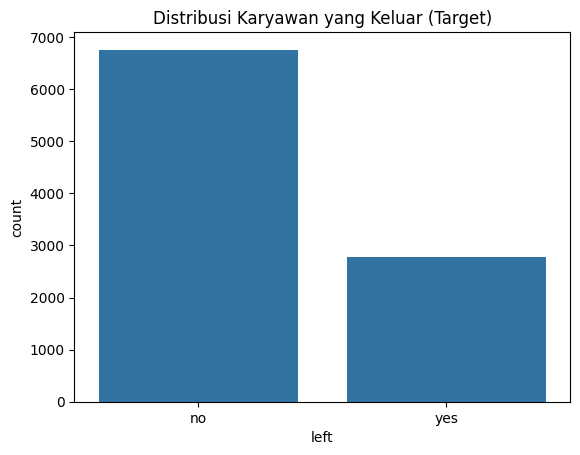

left
no     0.708176
yes    0.291824
Name: proportion, dtype: float64


In [6]:
sns.countplot(x='left', data=df)
plt.title('Distribusi Karyawan yang Keluar (Target)')
plt.show()

print(df['left'].value_counts(normalize=True))

> kolom Y di sini tidak rata yah, lebih banyak yang Y secara realita ini baik karena artinya dari 100% karyawan ada sekitar 70% yang memilih bertahan dan tidak resign

> plan nya adalah kita akan menggunakan class_weight='balanced' dengan random forest, stratify=y saat split agar proporse target tetap 70:30, dan kita akan mengutamakan metrik Recall karena kita ingin agar model dapat menangkap karyawan yang "ingin" resign (meminimalkan false negative) namun kita tetap menampilkan metrik lainnya precision dan F1-Score serta akurasi jika dibutuhkan

## distribusi fitur numerik (quantitative)

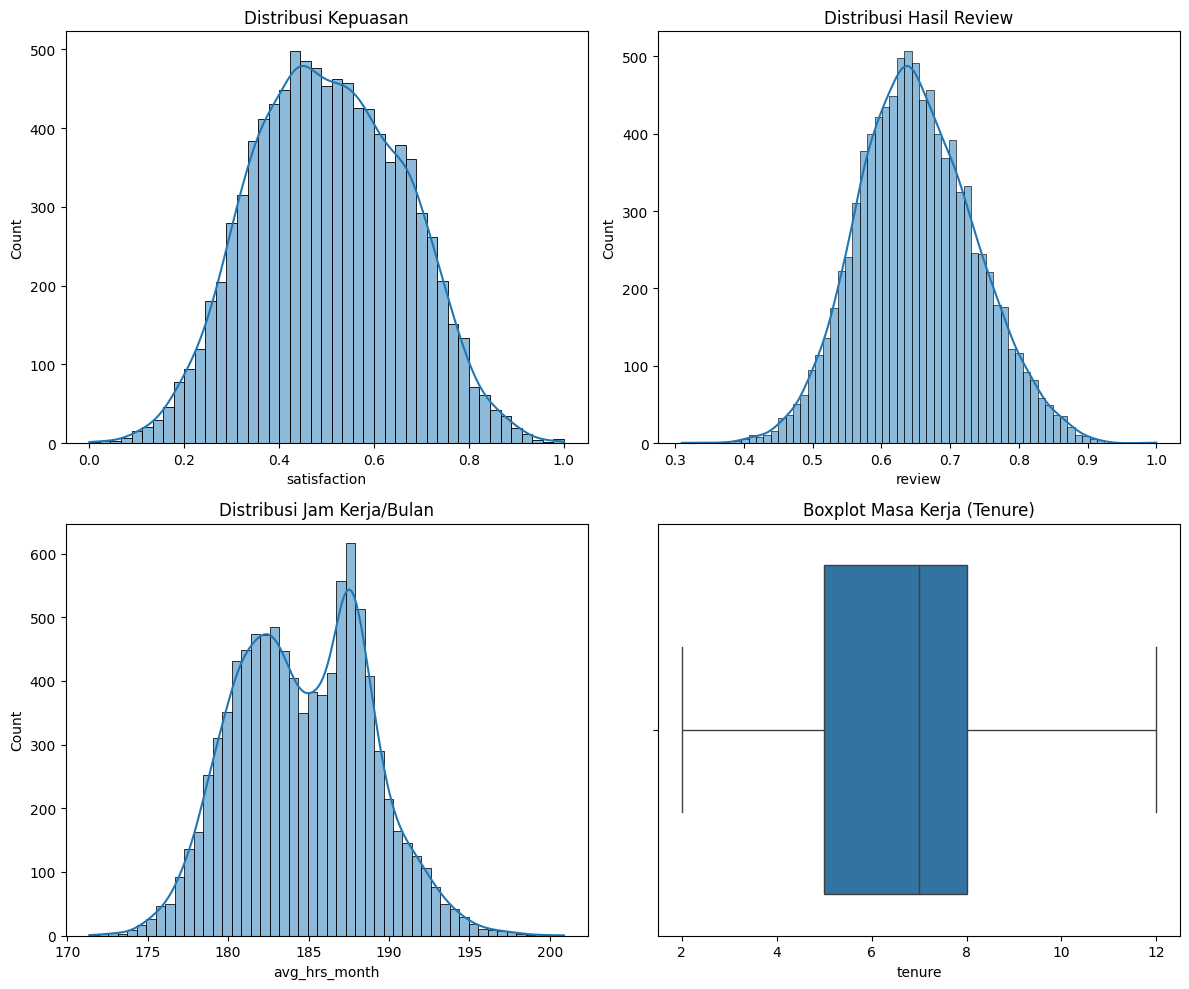

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.histplot(df['satisfaction'], kde=True, ax=axes[0,0]).set_title('Distribusi Kepuasan')
sns.histplot(df['review'], kde=True, ax=axes[0,1]).set_title('Distribusi Hasil Review')
sns.histplot(df['avg_hrs_month'], kde=True, ax=axes[1,0]).set_title('Distribusi Jam Kerja/Bulan')
sns.boxplot(x=df['tenure'], ax=axes[1,1]).set_title('Boxplot Masa Kerja (Tenure)')
plt.tight_layout()
plt.show()

> overall bagus yah satifaction dan review distribusi normal

> avg_hrs_month ini distribusi dengan dua puncak

> tenure tidak ada outlier

## cek hubungan 2 variable

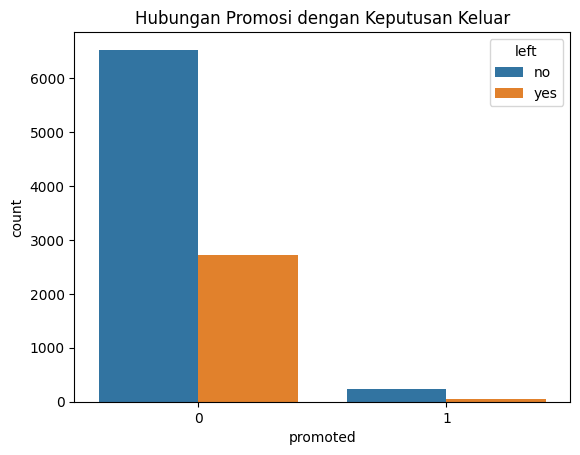

In [8]:
sns.countplot(x='promoted', hue='left', data=df)
plt.title('Hubungan Promosi dengan Keputusan Keluar')
plt.show()

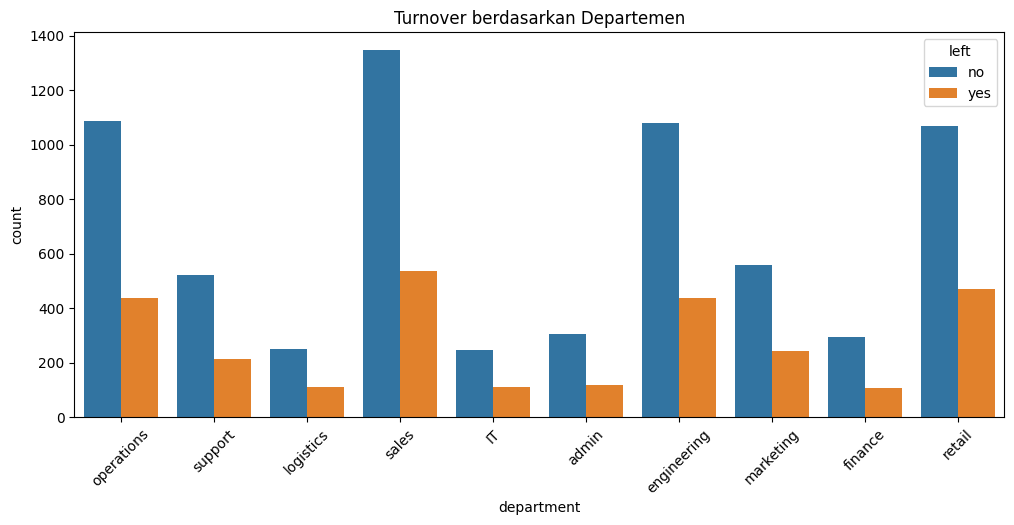

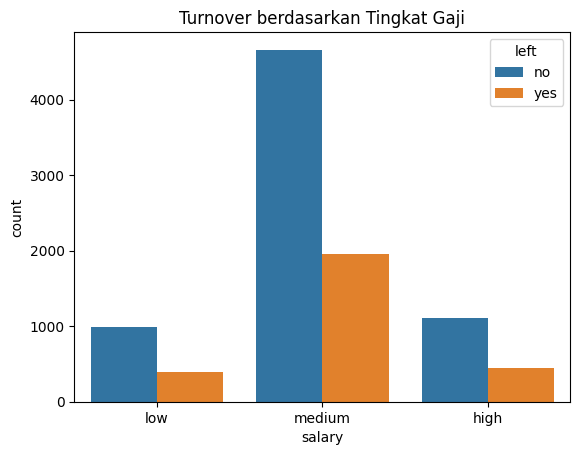

In [9]:
plt.figure(figsize=(12, 5))
sns.countplot(x='department', hue='left', data=df)
plt.title('Turnover berdasarkan Departemen')
plt.xticks(rotation=45)
plt.show()

sns.countplot(x='salary', hue='left', data=df, order=['low', 'medium', 'high'])
plt.title('Turnover berdasarkan Tingkat Gaji')
plt.show()

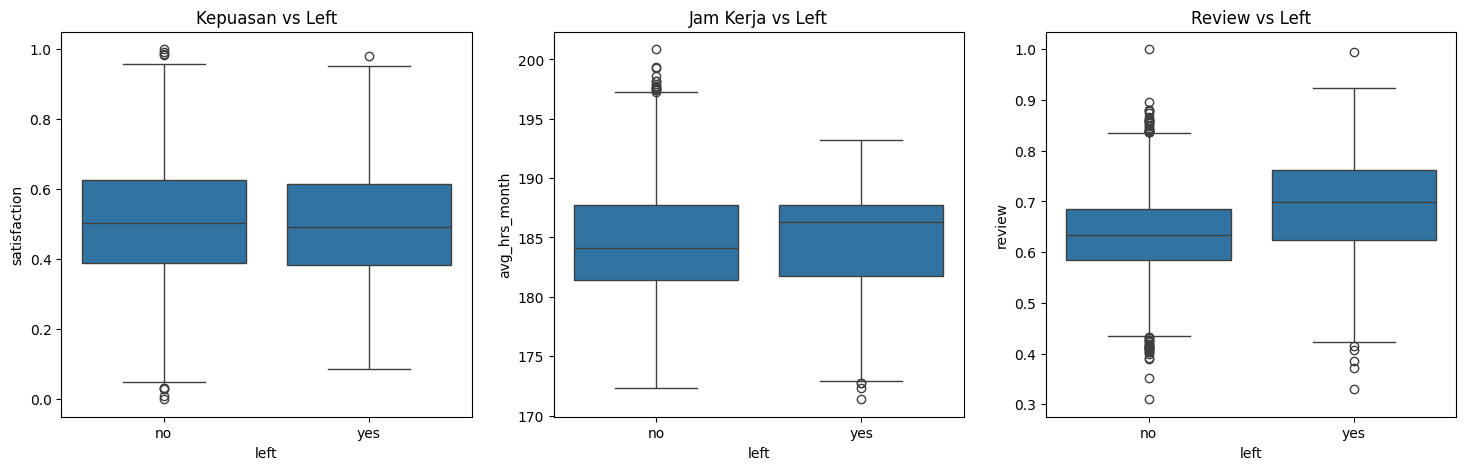

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(x='left', y='satisfaction', data=df, ax=axes[0]).set_title('Kepuasan vs Left')
sns.boxplot(x='left', y='avg_hrs_month', data=df, ax=axes[1]).set_title('Jam Kerja vs Left')
sns.boxplot(x='left', y='review', data=df, ax=axes[2]).set_title('Review vs Left')
plt.show()

review vs left: yang keluar cenderung adalah karyawan dengan review yang baik atau ada yang mendekati 1.0


## hubungan lebih dari 1 var

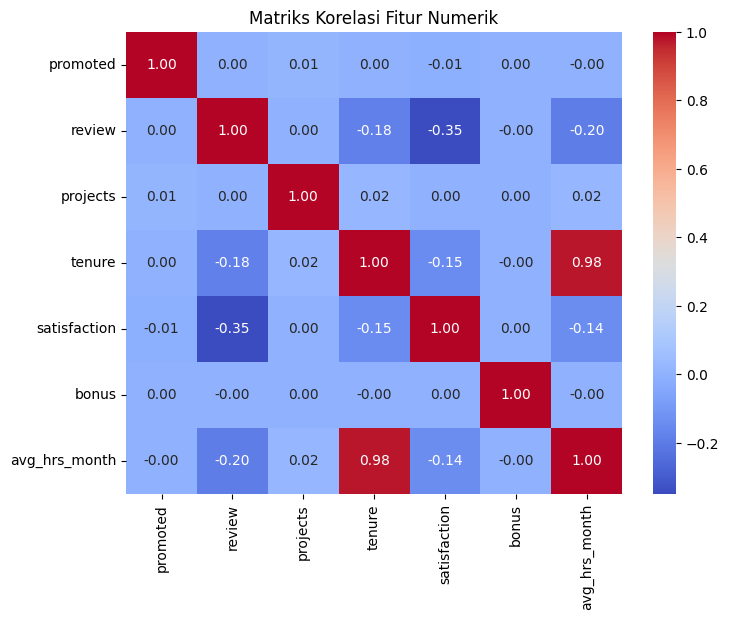

In [11]:
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(8, 6))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriks Korelasi Fitur Numerik')
plt.show()

> karena tenure dan avg_hrs_month saling bergantung satu sama lain makan nanti akan di drop agar tidak merusak interpretabilitas model kita

> Kesimpulan untuk model yang akan dibuat kita akan menggunakan hampir semua kolom kecuali avg_hrs_month

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

0. drop column yang tidak dibutuhkan

In [12]:
df = df.drop(columns=['avg_hrs_month'])

1. Menghapus atau Menangani Data Kosong (Missing Values)

In [13]:
df.isnull().sum()

,0
department,0
promoted,0
review,0
projects,0
salary,0
tenure,0
satisfaction,0
bonus,0
left,0


> karena 0 maka sudah bersih

2. Menghapus Data Duplikat

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
# df = df.drop_duplicates().reset_index(drop=True)

> tidak ada yang duplicated (bersih juga)

4. Deteksi dan Penanganan Outlier

In [16]:
def remove_outliers_iqr(dataframe, columns):
    clean_df = dataframe.copy()
    for col in columns:
        Q1 = clean_df[col].quantile(0.25)
        Q3 = clean_df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        clean_df = clean_df[(clean_df[col] >= lower_bound) & (clean_df[col] <= upper_bound)]
    return clean_df

In [17]:
print("before removing outliers")
df.shape

before removing outliers


(9540, 9)

In [18]:
df = remove_outliers_iqr(df, ['tenure', 'review'])
df.shape

(9484, 9)

5. Encoding Data Kategorikal

In [19]:
df.head(2)

,department,promoted,review,projects,salary,tenure,satisfaction,bonus,left
0,operations,0,0.577569,3,low,5.0,0.626759,0,no
1,operations,0,0.751900,3,medium,6.0,0.443679,0,no


In [20]:
# var y akan diubah jadi 1 0 (jadi binary)
df['left'] = df['left'].map({'yes': 1, 'no': 0})

In [21]:
df.head(2)

,department,promoted,review,projects,salary,tenure,satisfaction,bonus,left
0,operations,0,0.577569,3,low,5.0,0.626759,0,0
1,operations,0,0.751900,3,medium,6.0,0.443679,0,0


In [22]:
# salary karena ordinal jadi 0 1 2
df['salary'] = df['salary'].map({'low': 0, 'medium': 1, 'high': 2})

In [23]:
df.head(2)

,department,promoted,review,projects,salary,tenure,satisfaction,bonus,left
0,operations,0,0.577569,3,0,5.0,0.626759,0,0
1,operations,0,0.751900,3,1,6.0,0.443679,0,0


In [24]:
# one hot encode utk departement
df = pd.get_dummies(df, columns=['department'], drop_first=True)

In [25]:
df.head(2)

,promoted,review,projects,salary,tenure,satisfaction,bonus,left,department_admin,department_engineering,department_finance,department_logistics,department_marketing,department_operations,department_retail,department_sales,department_support
0,0,0.577569,3,0,5.0,0.626759,0,0,False,False,False,False,False,True,False,False,False
1,0,0.751900,3,1,6.0,0.443679,0,0,False,False,False,False,False,True,False,False,False


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9484 entries, 0 to 9539
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   promoted                9484 non-null   int64  
 1   review                  9484 non-null   float64
 2   projects                9484 non-null   int64  
 3   salary                  9484 non-null   int64  
 4   tenure                  9484 non-null   float64
 5   satisfaction            9484 non-null   float64
 6   bonus                   9484 non-null   int64  
 7   left                    9484 non-null   int64  
 8   department_admin        9484 non-null   bool   
 9   department_engineering  9484 non-null   bool   
 10  department_finance      9484 non-null   bool   
 11  department_logistics    9484 non-null   bool   
 12  department_marketing    9484 non-null   bool   
 13  department_operations   9484 non-null   bool   
 14  department_retail       9484 non-null   bool 

6. Binning (Pengelompokan Data) [tidak diperlukan pada case ini]

3. Normalisasi atau Standarisasi Fitur (terakhir sebelum digunakan model)

> scaling dilakukan setelah split untuk menghindari data leakage sehingga yang disimpan pada preprocessed dataset adalah 4 file dalam 1 folder

> ref: https://medium.com/@megha.natarajan/scaling-data-before-or-after-train-test-split-35e9a9a7453f

In [ ]:
folder_name = 'employee_churn_data_preprocessing'
os.makedirs(folder_name, exist_ok=True)
X = df.drop(columns=['left'])
y = df['left']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=44, stratify=y
)

numeric_cols = ['review', 'projects', 'tenure', 'satisfaction']
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

X_train.to_csv(os.path.join(folder_name, 'X_train_scaled.csv'), index=False)
X_test.to_csv(os.path.join(folder_name, 'X_test_scaled.csv'), index=False)
y_train.to_csv(os.path.join(folder_name, 'y_train.csv'), index=False)
y_test.to_csv(os.path.join(folder_name, 'y_test.csv'), index=False)

!ls {folder_name}

X_test_scaled.csv  X_train_scaled.csv  y_test.csv  y_train.csv
